# Principal Component Regression (PCR) Pipeline

Principal Component Regression (PCR) resolves collinearity by:
1. **PCA Step:** Performing Principal Component Analysis on the predictors matrix to extract orthogonal components.
2. **OLS Step:** Fitting an Ordinary Least Squares (OLS) regression on the subset of principal components.
This notebook builds a PCR workflow using Scikit-Learn `Pipeline`, fits it on a collinear 25-feature dataset, and plots predictions residuals using Matplotlib.



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

# Generate synthetic collinear dataset (400 samples, 25 features)
np.random.seed(215)
n_samples = 400
n_features = 25

# Generate 5 underlying latent factors
latent_factors = np.random.normal(0, 1.0, (n_samples, 5))

# Project 5 factors onto 25 collinear features
X = np.dot(latent_factors, np.random.uniform(-1, 1, (5, n_features))) + np.random.normal(0, 0.15, (n_samples, n_features))

# Target depends on the 5 latent factors
y = 1.8 * latent_factors[:, 0] - 2.5 * latent_factors[:, 1] + 0.9 * latent_factors[:, 2] + np.random.normal(0, 0.25, n_samples)

df_pcr = pd.DataFrame(X, columns=[f"Var_{i+1:02d}" for i in range(n_features)])
df_pcr['Target'] = y
df_pcr.head(10)



,Var_01,Var_02,Var_03,Var_04,Var_05,Var_06,Var_07,Var_08,Var_09,Var_10,Var_11,Var_12,Var_13,Var_14,Var_15,Var_16,Var_17,Var_18,Var_19,Var_20,Var_21,Var_22,Var_23,Var_24,Var_25,Target
0,1.000088,-0.359980,0.333628,0.802883,-0.749199,-1.413306,1.112999,0.853875,0.193924,1.219497,1.044233,-0.030017,0.741373,-1.153000,-0.600976,0.630978,0.146542,-0.481071,0.048532,1.298981,-0.111757,0.163133,-1.385486,0.949768,-0.382864,2.478624
1,-0.346851,-0.461696,0.414668,0.326074,-0.695496,1.384479,0.340498,-0.827450,0.948587,-1.377136,-0.329173,0.047658,0.512873,0.203331,-0.054431,-0.630026,0.201437,1.462552,-1.848132,-0.253772,-0.780145,0.106412,1.639290,0.866028,1.263267,-0.028108
2,-1.065410,1.299082,-1.171397,-1.313274,0.357405,0.115545,-0.876412,-0.568311,-2.987964,0.116576,-1.768642,0.201442,-0.019386,0.649638,0.166208,-0.897995,-0.205679,-1.044064,-0.218286,-0.406481,2.342024,1.651247,0.121851,-0.428923,-0.873045,-5.025047
3,1.988297,-1.374165,-1.525359,1.598675,-0.870127,-2.795469,1.146176,2.228269,-1.789179,2.575905,-1.398074,0.451982,1.835148,-2.926264,-0.587918,1.098601,-0.662403,-0.385975,1.695894,3.333756,-0.373918,0.374352,-1.037448,1.494168,-1.287584,3.798535
4,3.108352,-3.555295,-1.683860,2.653614,-1.574168,-2.938934,1.414664,1.671924,-1.660252,1.948905,-3.395244,0.969557,2.422226,-4.204202,-0.216582,0.757657,-0.721406,0.852493,0.239395,5.129431,-1.847324,0.051249,1.134722,3.536689,-0.228570,6.931414
5,-2.076667,0.753939,0.396570,-0.188799,-0.739428,1.649746,-0.717849,-0.694407,-0.380449,-0.550166,0.231517,-0.205527,-0.952662,0.604593,-0.044898,-0.262163,-0.134215,0.564555,-1.778588,-1.419460,0.852617,1.235834,1.121787,-0.317040,1.061263,-2.742071
6,-0.897454,0.951348,-0.884805,-1.951348,0.720118,0.578440,-0.964191,-1.536761,-2.474671,-1.226016,-2.307452,0.546096,0.209293,1.333924,0.032657,-1.583561,-0.004069,-0.299976,-0.794709,-0.808011,1.618409,1.188851,1.508244,0.155018,-0.632945,-5.589842
7,0.539152,-0.235218,-0.001305,0.228710,-0.770454,-0.936501,0.834667,0.180410,0.032438,0.374708,0.878201,0.231141,0.885514,-0.727286,-0.525691,0.550280,0.419299,-0.300523,-0.422612,1.105237,0.024160,-0.105447,-1.145099,0.335613,-0.117099,1.496603
8,3.285631,-1.410107,-0.377258,-0.485739,0.465219,-1.778498,2.017145,-0.878142,1.107346,-0.383586,-0.702243,1.298992,2.782698,-0.450981,-0.611144,-0.098781,1.066509,0.068336,0.102078,2.456659,-1.458880,-1.412005,0.538166,2.441791,-0.453583,3.628175
9,0.114776,1.225424,-0.134826,-2.510712,1.844388,0.658419,-0.604077,-1.602831,-0.048657,-1.681526,-0.504599,0.715570,-0.286618,2.857040,0.591995,-1.330113,0.525693,-0.482842,0.580921,-1.297505,0.790887,-0.569609,0.488199,-1.176480,-0.691930,-3.782646


## PCR Pipeline Training & Evaluation

We build a Scikit-Learn Pipeline combining `StandardScaler`, `PCA(n_components=5)`, and `LinearRegression`. We evaluate performance using test Root Mean Squared Error (RMSE).



In [2]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Construct PCR pipeline
pcr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=5)),
    ('regression', LinearRegression())
])

pcr_pipeline.fit(X_train, y_train)

# Predict targets
y_pred = pcr_pipeline.predict(X_test)

# Calculate RMSE and R2 scores
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"PCR Pipeline Test RMSE: {rmse:.4f}")
print(f"PCR Pipeline Test R²:   {r2:.4f}")



PCR Pipeline Test RMSE: 0.3127
PCR Pipeline Test R²:   0.9893


## Residuals Distribution Plot

Using Matplotlib, we plot predictions residuals ($y_{test} - y_{pred}$) to verify homoscedasticity and check error normal distributions.



<cell>:22: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



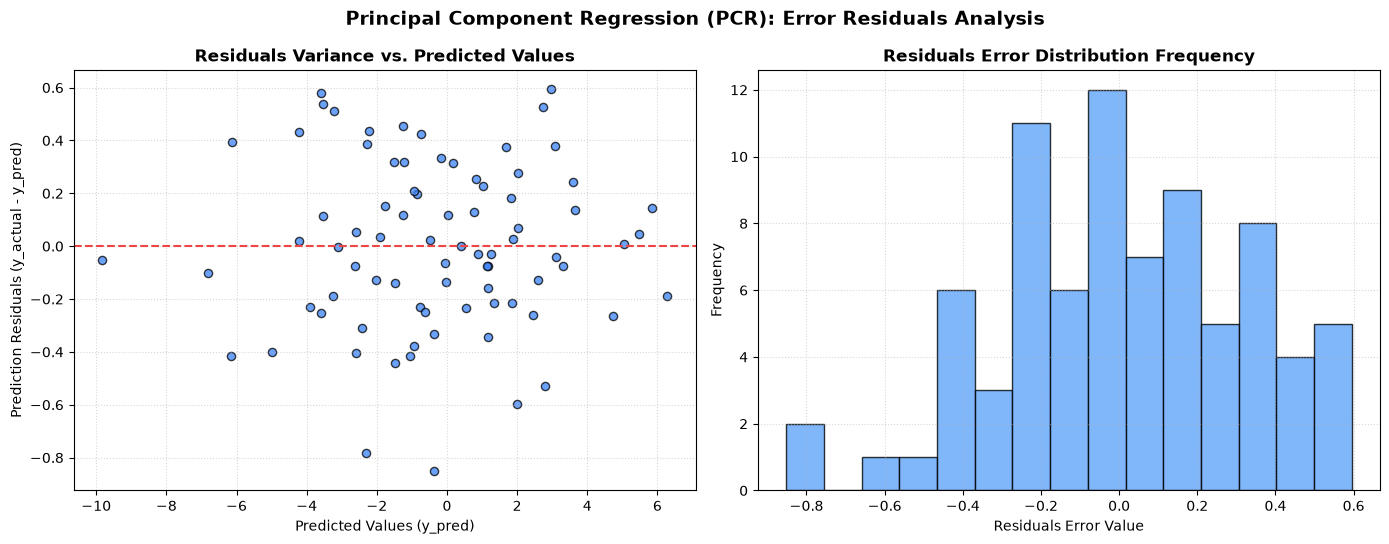

In [3]:
residuals = y_test - y_pred

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

# 1. Residuals vs Predicted scatter plot
ax1.scatter(y_pred, residuals, c='#3B82F6', edgecolors='k', alpha=0.75, s=35)
ax1.axhline(0.0, color='#EF4444', linestyle='--', linewidth=1.5)
ax1.set_title('Residuals Variance vs. Predicted Values', fontsize=12, fontweight='bold')
ax1.set_xlabel('Predicted Values (y_pred)')
ax1.set_ylabel('Prediction Residuals (y_actual - y_pred)')
ax1.grid(True, linestyle=':', alpha=0.5)

# 2. Residuals histogram distribution
ax2.hist(residuals, bins=15, color='#60A5FA', edgecolor='black', alpha=0.8)
ax2.set_title('Residuals Error Distribution Frequency', fontsize=12, fontweight='bold')
ax2.set_xlabel('Residuals Error Value')
ax2.set_ylabel('Frequency')
ax2.grid(True, linestyle=':', alpha=0.5)

plt.suptitle('Principal Component Regression (PCR): Error Residuals Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
